=== Real-data best-fit parameters used ===
DVCH:
  H0        = 73.05445000
  Om0       = 0.37045700
  n         = 0.21033200
  log10beta = -1.00000000
  rd        = 136.87232400
  M         = -0.00216700
  Or0       = 0.00007826
  Ol0       = 0.62946474

LCDM:
  H0        = 73.51671700
  Om0       = 0.31073900
  rd        = 136.83619000
  M         = -0.00007300
  Or0       = 0.00007728
  Ol0       = 0.68918372

=== Kinematic diagnostics ===
DVCH  transition redshift z_t = 0.7075
LCDM  transition redshift z_t = 0.6426
Difference Δz_t = +0.0649

=== Effective-EOS diagnostic ===
min[w_eff(z)] full plotted range  = -1.65748
max[w_eff(z)] full plotted range  = -0.86960
min[w_eff(z)] late-time range     = -1.22063
max[w_eff(z)] late-time range     = -0.86960


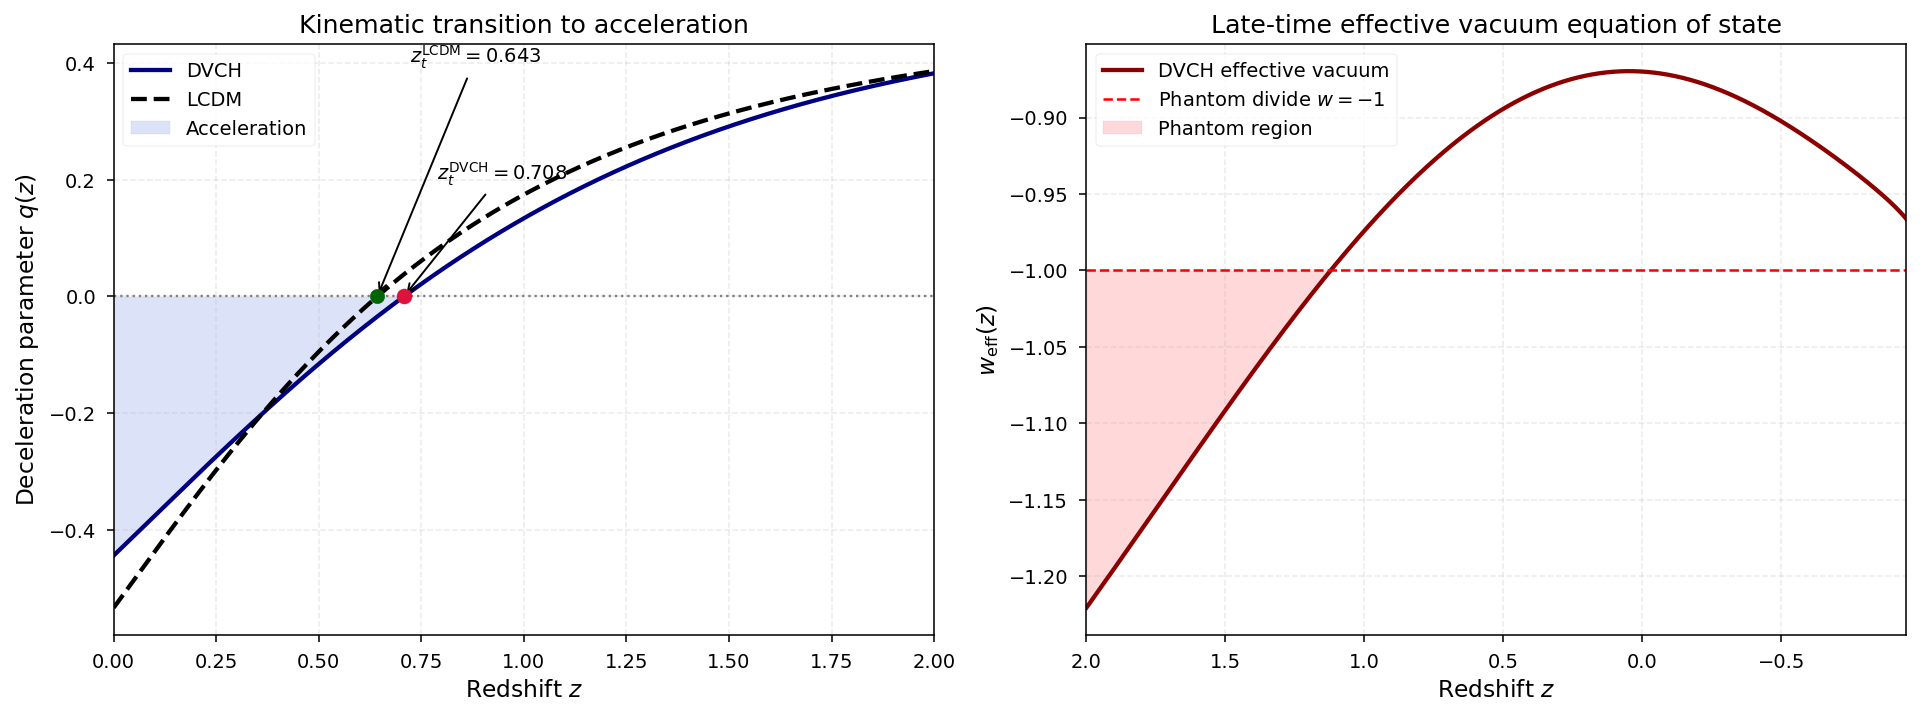

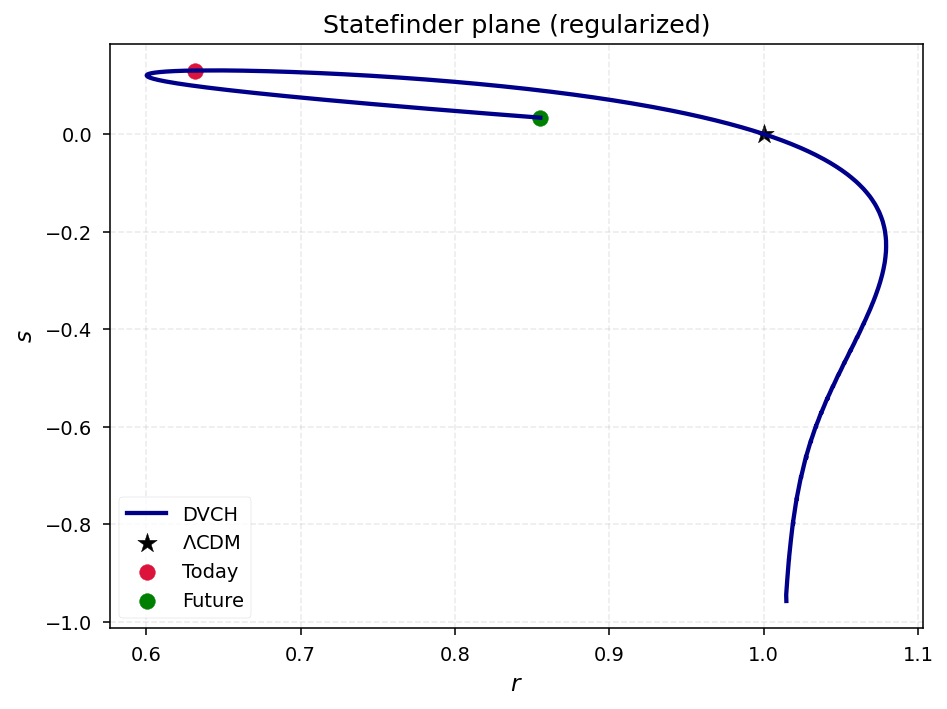

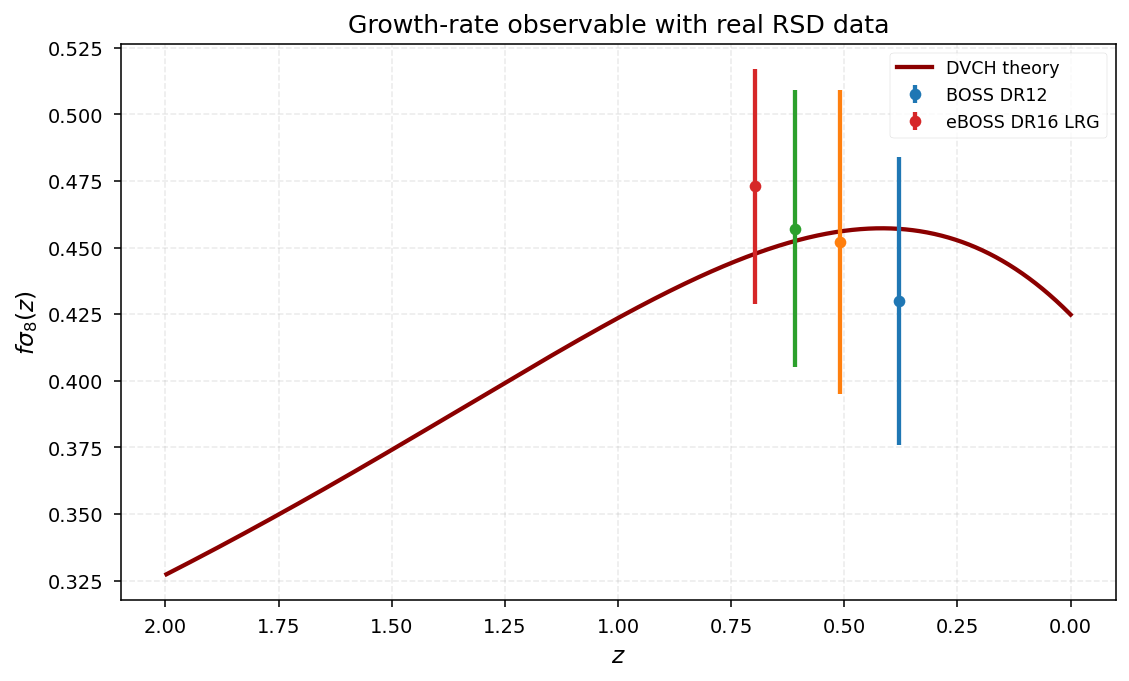

In [3]:
# ============================================================
# MASTER CELL FINAL CORREGIDA
# DVCH real-data best-fit:
#   - background
#   - q(z)
#   - w_eff(z)
#   - regularized statefinder
#   - fσ8 with real RSD points
# Self-contained: no previous cells required
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.optimize import brentq

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.2,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# ------------------------------------------------------------
# Real-data refined best-fit parameters
# ------------------------------------------------------------
dvch = {
    "H0": 73.054450,
    "Om0": 0.370457,
    "n": 0.210332,
    "log10beta": -1.000000,
    "rd": 136.872324,
    "M": -0.002167,
}

lcdm = {
    "H0": 73.516717,
    "Om0": 0.310739,
    "rd": 136.836190,
    "M": -0.000073,
}

TCMB = 2.7255
NEFF = 3.046

def omega_r0_from_h(h, Tcmb=TCMB, Neff=NEFF):
    omega_gamma = 2.469e-5 * (Tcmb / 2.7255) ** 4 / h**2
    return omega_gamma * (1.0 + 0.2271 * Neff)

dvch["Or0"] = omega_r0_from_h(dvch["H0"] / 100.0)
dvch["Ol0"] = 1.0 - dvch["Om0"] - dvch["Or0"]
dvch["beta"] = 10.0 ** dvch["log10beta"]

lcdm["Or0"] = omega_r0_from_h(lcdm["H0"] / 100.0)
lcdm["Ol0"] = 1.0 - lcdm["Om0"] - lcdm["Or0"]

print("=== Real-data best-fit parameters used ===")
print("DVCH:")
for k in ["H0", "Om0", "n", "log10beta", "rd", "M", "Or0", "Ol0"]:
    print(f"  {k:9s} = {dvch[k]:.8f}")

print("\nLCDM:")
for k in ["H0", "Om0", "rd", "M", "Or0", "Ol0"]:
    print(f"  {k:9s} = {lcdm[k]:.8f}")

# ------------------------------------------------------------
# DVCH background: solve for Omega_m(z), recover E(z), Omega_r, Omega_L
# ------------------------------------------------------------
def dvch_background_from_Om(z, Om, pars):
    Om = max(float(Om), 1e-14)
    z = float(z)

    Or = pars["Or0"] * (1.0 + z) ** 4
    beta = pars["beta"]
    n = pars["n"]
    Om0 = pars["Om0"]
    Ol0 = pars["Ol0"]

    C = Ol0 * (1.0 + beta) * (Om / Om0) ** n

    # x = E^2 satisfies: x = Or + Om + C/(1 + beta x)
    if abs(beta) < 1e-14:
        x = Or + Om + C
    else:
        a = beta
        b = 1.0 - beta * (Or + Om)
        c = -(Or + Om + C)
        disc = max(b * b - 4.0 * a * c, 0.0)
        x1 = (-b + np.sqrt(disc)) / (2.0 * a)
        x2 = (-b - np.sqrt(disc)) / (2.0 * a)
        x = max(x1, x2)

    x = max(x, 1e-14)
    E = np.sqrt(x)
    Ol = C / (1.0 + beta * x)
    return E, Or, Ol

def qtilde_dvch(z, Om, pars):
    E, Or, Ol = dvch_background_from_Om(z, Om, pars)
    beta = pars["beta"]
    n = pars["n"]

    denom = 1.0 + n * Ol / max(Om, 1e-14)
    bracket = n - (beta / (1.0 + beta * E**2)) * ((4.0 * Or + 3.0 * Om) / 3.0)

    qtil = -(E * Ol / denom) * bracket
    return qtil, E, Or, Ol

def rhs_dvch(z, y, pars):
    Om = max(float(y[0]), 1e-14)
    qtil, E, Or, Ol = qtilde_dvch(z, Om, pars)
    dOm_dz = (3.0 * Om + 3.0 * qtil / E) / (1.0 + z)
    return [dOm_dz]

def integrate_dvch(pars, z_future=-0.95, z_max=5.0, n_past=1800, n_future=800):
    z_past = np.linspace(0.0, z_max, n_past)
    z_fut = np.linspace(0.0, z_future, n_future)

    sol_past = solve_ivp(
        rhs_dvch,
        (0.0, z_max),
        [pars["Om0"]],
        t_eval=z_past,
        args=(pars,),
        method="Radau",
        rtol=1e-8,
        atol=1e-10,
    )

    sol_fut = solve_ivp(
        rhs_dvch,
        (0.0, z_future),
        [pars["Om0"]],
        t_eval=z_fut,
        args=(pars,),
        method="Radau",
        rtol=1e-8,
        atol=1e-10,
    )

    if not sol_past.success:
        raise RuntimeError("Past integration failed: " + sol_past.message)
    if not sol_fut.success:
        raise RuntimeError("Future integration failed: " + sol_fut.message)

    z = np.concatenate([sol_fut.t[::-1][:-1], sol_past.t])
    Om = np.concatenate([sol_fut.y[0][::-1][:-1], sol_past.y[0]])

    E = np.empty_like(z)
    Or = np.empty_like(z)
    Ol = np.empty_like(z)
    qtil = np.empty_like(z)

    for i, (zz, om) in enumerate(zip(z, Om)):
        qtil[i], E[i], Or[i], Ol[i] = qtilde_dvch(zz, om, pars)

    return {"z": z, "E": E, "Om": Om, "Or": Or, "Ol": Ol, "qtil": qtil}

def lcdm_background(pars, z):
    z = np.asarray(z)
    Om = pars["Om0"] * (1.0 + z) ** 3
    Or = pars["Or0"] * (1.0 + z) ** 4
    Ol = np.full_like(z, pars["Ol0"], dtype=float)
    E = np.sqrt(Om + Or + Ol)
    return {"E": E, "Om": Om, "Or": Or, "Ol": Ol}

# ------------------------------------------------------------
# Derived observables
# ------------------------------------------------------------
def q_from_E(z, E):
    dE_dz = np.gradient(E, z, edge_order=2)
    return -1.0 + (1.0 + z) * dE_dz / E

def w_eff_dark(E, Ol, qtil):
    return -1.0 - qtil / (E * np.maximum(Ol, 1e-14))

def transition_redshift(z, q, zmin=0.0, zmax=2.0):
    mask = (z >= zmin) & (z <= zmax)
    zz = z[mask]
    qq = q[mask]

    crossings = np.where(np.diff(np.sign(qq)) != 0)[0]
    if len(crossings) == 0:
        return np.nan

    i = crossings[0]
    f = interp1d(zz[i:i+2], qq[i:i+2], kind="linear", fill_value="extrapolate")
    return brentq(lambda x: float(f(x)), float(zz[i]), float(zz[i+1]))

# ------------------------------------------------------------
# Run background
# ------------------------------------------------------------
dvch_bg = integrate_dvch(dvch, z_future=-0.95, z_max=5.0)
z = dvch_bg["z"]

E_dvch = dvch_bg["E"]
Om_dvch = dvch_bg["Om"]
Or_dvch = dvch_bg["Or"]
Ol_dvch = dvch_bg["Ol"]
qtil_dvch = dvch_bg["qtil"]

lcdm_bg = lcdm_background(lcdm, z)
E_lcdm = lcdm_bg["E"]

q_dvch = q_from_E(z, E_dvch)
q_lcdm = q_from_E(z, E_lcdm)
w_dvch = w_eff_dark(E_dvch, Ol_dvch, qtil_dvch)

zt_dvch = transition_redshift(z, q_dvch, 0.0, 2.0)
zt_lcdm = transition_redshift(z, q_lcdm, 0.0, 2.0)

mask_q = (z >= 0.0) & (z <= 2.0)
mask_w = (z >= -0.95) & (z <= 5.0)
mask_w_late = (z >= -0.95) & (z <= 2.0)

print("\n=== Kinematic diagnostics ===")
print(f"DVCH  transition redshift z_t = {zt_dvch:.4f}")
print(f"LCDM  transition redshift z_t = {zt_lcdm:.4f}")
print(f"Difference Δz_t = {zt_dvch - zt_lcdm:+.4f}")

print("\n=== Effective-EOS diagnostic ===")
print(f"min[w_eff(z)] full plotted range  = {np.min(w_dvch[mask_w]):.5f}")
print(f"max[w_eff(z)] full plotted range  = {np.max(w_dvch[mask_w]):.5f}")
print(f"min[w_eff(z)] late-time range     = {np.min(w_dvch[mask_w_late]):.5f}")
print(f"max[w_eff(z)] late-time range     = {np.max(w_dvch[mask_w_late]):.5f}")

# ------------------------------------------------------------
# Statefinder regularized
# ------------------------------------------------------------
dq_dz = np.gradient(q_dvch, z, edge_order=2)
r_arr = 2.0 * q_dvch**2 + q_dvch + (1.0 + z) * dq_dz

s_den = 3.0 * (q_dvch - 0.5)
s_arr = np.full_like(r_arr, np.nan)
safe = np.abs(s_den) > 5e-3
s_arr[safe] = (r_arr[safe] - 1.0) / s_den[safe]

idx_today = np.argmin(np.abs(z))
idx_future = np.argmin(np.abs(z - (-0.95)))

# ------------------------------------------------------------
# FIGURE 1: q(z) + late-time w_eff(z)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0), constrained_layout=True)

# Left panel: q(z)
ax = axes[0]
zq = z[mask_q]
qd = q_dvch[mask_q]
ql = q_lcdm[mask_q]

ax.plot(zq, qd, color="navy", label="DVCH")
ax.plot(zq, ql, color="black", ls="--", label="LCDM")
ax.axhline(0.0, color="gray", lw=1.2, ls=":")
ax.fill_between(zq, qd, 0.0, where=(qd < 0.0), color="royalblue", alpha=0.18, label="Acceleration")

if np.isfinite(zt_dvch):
    ax.scatter(zt_dvch, 0.0, s=60, color="crimson", zorder=5)
    ax.annotate(
        rf"$z_t^{{\rm DVCH}}={zt_dvch:.3f}$",
        xy=(zt_dvch, 0.0),
        xytext=(zt_dvch + 0.08, 0.20),
        arrowprops=dict(arrowstyle="->", lw=1),
        fontsize=10,
    )

if np.isfinite(zt_lcdm):
    ax.scatter(zt_lcdm, 0.0, s=55, color="darkgreen", zorder=5)
    ax.annotate(
        rf"$z_t^{{\rm LCDM}}={zt_lcdm:.3f}$",
        xy=(zt_lcdm, 0.0),
        xytext=(zt_lcdm + 0.08, 0.40),
        arrowprops=dict(arrowstyle="->", lw=1),
        fontsize=10,
    )

ax.set_xlim(0, 2)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel("Deceleration parameter $q(z)$")
ax.set_title("Kinematic transition to acceleration")
ax.legend(frameon=True, loc="best")

# Right panel: late-time w_eff(z)
ax = axes[1]
zw = z[mask_w_late]
ww = w_dvch[mask_w_late]

ax.plot(zw, ww, color="darkred", lw=2.2, label="DVCH effective vacuum")
ax.axhline(-1.0, color="red", lw=1.3, ls="--", label="Phantom divide $w=-1$")
ax.fill_between(zw, ww, -1.0, where=(ww < -1.0), color="red", alpha=0.15, label="Phantom region")
ax.set_xlim(2.0, -0.95)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"$w_{\rm eff}(z)$")
ax.set_title("Late-time effective vacuum equation of state")
ax.legend(frameon=True, loc="best")

plt.savefig("q_and_weff_final_corrected.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# FIGURE 2: statefinder regularized
# ------------------------------------------------------------
plt.figure(figsize=(6.9, 5.2))
plt.plot(r_arr[safe], s_arr[safe], color="darkblue", lw=2.2, label="DVCH")
plt.scatter([1.0], [0.0], color="black", marker="*", s=110, label=r"$\Lambda$CDM")
if safe[idx_today]:
    plt.scatter([r_arr[idx_today]], [s_arr[idx_today]], color="crimson", s=65, label="Today")
if safe[idx_future]:
    plt.scatter([r_arr[idx_future]], [s_arr[idx_future]], color="green", s=65, label="Future")
plt.xlabel(r"$r$")
plt.ylabel(r"$s$")
plt.title("Statefinder plane (regularized)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("statefinder_final_corrected.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# FIGURE 3: fσ8 with real RSD points
# ------------------------------------------------------------
a_all = 1.0 / (1.0 + z)
order = np.argsort(a_all)

a_sorted = a_all[order]
E_sorted = E_dvch[order]
Om_sorted = Om_dvch[order] / np.maximum(E_sorted**2, 1e-30)

valid = np.isfinite(a_sorted) & np.isfinite(E_sorted) & np.isfinite(Om_sorted)
a_sorted = a_sorted[valid]
E_sorted = E_sorted[valid]
Om_sorted = Om_sorted[valid]

unique_mask = np.r_[True, np.diff(a_sorted) > 1e-12]
a_sorted = a_sorted[unique_mask]
E_sorted = E_sorted[unique_mask]
Om_sorted = Om_sorted[unique_mask]

E_of_a = PchipInterpolator(a_sorted, E_sorted, extrapolate=False)
Om_of_a = PchipInterpolator(a_sorted, Om_sorted, extrapolate=False)

def gamma_q_eff(a):
    return 0.02 / max(a, 1e-6)

def growth_rhs(a, y):
    D, Dp = y
    Om_a = float(Om_of_a(a))

    da = 1e-4
    ap = min(a + da, a_sorted[-1])
    am = max(a - da, a_sorted[0])

    dlnH_da = (np.log(float(E_of_a(ap))) - np.log(float(E_of_a(am)))) / (ap - am)

    Gq = gamma_q_eff(a)
    A = 3.0 / a + dlnH_da + Gq / a
    B = 1.5 * Om_a / a**2

    Dpp = -A * Dp + B * D
    return [Dp, Dpp]

a_min = max(a_sorted[0], 1e-3)
a_max = 1.0
a_growth = np.linspace(a_min, a_max, 700)

sol_g = solve_ivp(
    growth_rhs,
    (a_min, a_max),
    [a_min, 1.0],
    t_eval=a_growth,
    rtol=1e-6,
    atol=1e-8,
)

D = sol_g.y[0]
Dp = sol_g.y[1]
f = a_growth * Dp / np.maximum(D, 1e-30)
sigma8_0 = 0.811
fs8 = f * sigma8_0 * (D / D[-1])
z_growth = 1.0 / a_growth - 1.0

rsd_data = np.array([
    [0.38, 0.430, 0.054, "BOSS DR12"],
    [0.51, 0.452, 0.057, "BOSS DR12"],
    [0.61, 0.457, 0.052, "BOSS DR12"],
    [0.698, 0.473, 0.044, "eBOSS DR16 LRG"],
], dtype=object)

mask_fs8 = z_growth <= 2.0

plt.figure(figsize=(8.2, 5.0))
plt.plot(z_growth[mask_fs8], fs8[mask_fs8], color="darkred", lw=2.2, label=r"DVCH theory")

for row in rsd_data:
    z_i = float(row[0])
    y_i = float(row[1])
    e_i = float(row[2])
    lbl = str(row[3])
    plt.errorbar(z_i, y_i, yerr=e_i, fmt="o", ms=6, capsize=3, label=lbl)

plt.gca().invert_xaxis()
plt.xlabel(r"$z$")
plt.ylabel(r"$f\sigma_8(z)$")
plt.title(r"Growth-rate observable with real RSD data")
plt.grid(alpha=0.25)

handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        new_handles.append(h)
        new_labels.append(l)

plt.legend(new_handles, new_labels, fontsize=9)
plt.tight_layout()
plt.savefig("fsigma8_rsd_realdata_final_corrected.pdf", bbox_inches="tight")
plt.show()